## Library Imports & Output Dir

In [1]:
import re
from pathlib import Path
import pandas as pd
import json
import os
import math
from math import isfinite
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
import csv
from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact
from statsmodels.formula.api import mixedlm
import matplotlib.pyplot as plt


print("Libraries loaded successfully")

OUT_DIR = Path('tables')
OUT_DIR.mkdir(exist_ok=True)

print("Output directory created")

Libraries loaded successfully
Output directory created


## Table of number & percentage of users picking credential for website in survey

In [2]:
# Parse category and credential names from file

DATA_FILE = Path('data/user_survey_percentage_per_category.txt')

def parse_category_percentages(path):
    """Parse the text file and return (categories, credentials, mapping)
    mapping is a dict of credential -> {category: percent_string}
    """
    mapping = {}
    categories = []
    current_cat = None
    
    cat_re = re.compile(r"^-\s*(.+):\s*$")
    line_re = re.compile(r"^\s*-\s*([^:]+):\s*([0-9]+(?:\.[0-9]+)?)%")

    with open(path, 'r', encoding='utf-8') as f:
        for raw in f:
            line = raw.rstrip('\n')
            if not line.strip():
                continue
            mcat = cat_re.match(line)
            if mcat:
                current_cat = mcat.group(1).strip()
                categories.append(current_cat)
                continue
            if current_cat is None:
                continue
            m = line_re.match(line)
            if m:
                cred = m.group(1).strip()
                percent = m.group(2).strip()
                pct_str = f"{percent}%"
                if cred not in mapping:
                    mapping[cred] = {}
                mapping[cred][current_cat] = pct_str
            else:
                # line might contain extra info like counts; try a more permissive parse
                m2 = re.match(r"^\s*-\s*([^:]+):\s*([0-9]+(?:\.[0-9]+)?)%\s*\(.*\)", line)
                if m2:
                    cred = m2.group(1).strip()
                    percent = m2.group(2).strip()
                    pct_str = f"{percent}%"
                    if cred not in mapping:
                        mapping[cred] = {}
                    mapping[cred][current_cat] = pct_str
                else:
                    # Could not parse line; skip
                    print(f"Warning: could not parse line: {line}")
                    continue

    return categories, sorted(mapping.keys()), mapping

categories, credentials, mapping = parse_category_percentages(DATA_FILE)
print(f"Found {len(categories)} categories and {len(credentials)} credentials")

Found 17 categories and 14 credentials


In [3]:
# Build DataFrame with credentials as rows and categories as columns
df = pd.DataFrame(index=credentials, columns=categories)
for cred in credentials:
    for cat in categories:
        val = mapping.get(cred, {}).get(cat, '')
        df.at[cred, cat] = val

out_csv = OUT_DIR / 'credential_percentage_per_category.csv'
df.to_csv(out_csv, index=True)
print('Wrote CSV:', out_csv)

# Also write a numeric CSV (float percentages)
df_numeric = df.replace('', pd.NA).applymap(lambda x: float(x.strip('%')) if isinstance(x, str) and x.endswith('%') else pd.NA)
out_csv_num = OUT_DIR / 'credential_percentage_per_category_numeric.csv'
df_numeric.to_csv(out_csv_num, index=True)
print('Wrote numeric CSV:', out_csv_num)

Wrote CSV: tables\credential_percentage_per_category.csv
Wrote numeric CSV: tables\credential_percentage_per_category_numeric.csv


C:\Users\zingg\AppData\Local\Temp\ipykernel_16488\2012596638.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_numeric = df.replace('', pd.NA).applymap(lambda x: float(x.strip('%')) if isinstance(x, str) and x.endswith('%') else pd.NA)


## Generate Tables for the different user study justification classes

In [4]:
# Doc Locations
CONTROL_FILE = Path('data/user_study_control_results_no_agg.txt')
PHASE1_FILE = Path('data/survey_responses_for_user_study_scenarios.txt')
WEBSITE_JSON = Path('files/user_study_website_data.json')

In [5]:
def parse_control_file(path):
    # Returns dict mapping scenario short key (e.g. S1_1) -> list of control scenario entries
    # each entry: {'id': id, 'yes': int, 'no': int, 'total': int} 
    groups = {}
    cur_group = None
    # read lines stripping whitespace/newline
    with open(path, 'r', encoding='utf-8') as f:
        lines = [ln.rstrip() for ln in f]
    i = 0
    while i < len(lines):
        ln = lines[i].strip()
        m = re.match(r'^Group[:\s]*?(S[0-9]+_[0-9]+)', ln)
        if m:
            cur_group = m.group(1)
            groups[cur_group] = []
            i += 1
            continue
        if cur_group and ln.startswith('Control Scenario:'):
            parts = ln.split(':', 1)
            cid = parts[1].strip() if len(parts) > 1 else ''
            yes = no = total = None
            if i+1 < len(lines):
                m_yes = re.search(r'Yes:\s*([0-9]+)', lines[i+1])
                if m_yes:
                    yes = int(m_yes.group(1))
            if i+2 < len(lines):
                m_no = re.search(r'No:\s*([0-9]+)', lines[i+2])
                if m_no:
                    no = int(m_no.group(1))
            if i+3 < len(lines):
                m_total = re.search(r'Total:\s*([0-9]+)', lines[i+3])
                if m_total:
                    total = int(m_total.group(1))
            entry = {'id': cid, 'yes': yes or 0, 'no': no or 0, 'total': total or 0}
            groups[cur_group].append(entry)
            i += 4
            continue
        i += 1
    return groups

def parse_phase1_file(path):
    # returns dict: Sx_y -> {'pct': float, 'total': int, 'yes': int} 
    out = {}
    with open(path, 'r', encoding='utf-8') as f:
        text = f.read()
    for m in re.finditer(r'-?\s*(S[0-9]+_[0-9]+)\s*:\s*([0-9]+(?:\.[0-9]+)?)%\s*\(\s*([0-9]+)\s*\)', text):
        sid = m.group(1)
        pct = float(m.group(2))
        total = int(m.group(3))
        yes = int(round(pct / 100.0 * total))
        out[sid] = {'pct': pct, 'total': total, 'yes': yes}
    return out

# load inputs
control = parse_control_file(CONTROL_FILE)
phase1 = parse_phase1_file(PHASE1_FILE)
with open(WEBSITE_JSON, 'r', encoding='utf-8') as f:
    website_map = json.load(f)

print('Loaded', len(control), 'control groups,', len(phase1), 'phase1 entries,', len(website_map), 'website entries')

Loaded 50 control groups, 50 phase1 entries, 50 website entries


In [6]:
def choose_control_entry(group_key, entries):
    if not entries:
        return None
    if group_key.startswith('S2'):
        for e in entries:
            if '_all_good_' in e['id'] or e['id'].startswith('s2_all_good'):
                return e
    if group_key.startswith('S4'):
        for e in entries:
            if '_no_purpose_' in e['id'] or 'no_purpose' in e['id']:
                return e
    return entries[0]


def compare_counts(control_yes, control_total, phase1_yes, phase1_total):
    # Build contingency table and always use Fisher's exact test for comparison.
    a = int(control_yes)
    b = int(control_total - control_yes)
    c = int(phase1_yes)
    d = int(phase1_total - phase1_yes)
    # ensure non-negative
    b = max(0, b)
    d = max(0, d)
    table = np.array([[a, b], [c, d]])
    # if either total is zero, return NA
    if (control_total == 0) or (phase1_total == 0):
        return {'test': 'NA', 'p_value': None, 'stat': None, 'method': 'no_data', 'expected_min': None}
    # try to compute expected counts for reporting 
    try:
        _, _, _, expected = chi2_contingency(table, correction=False)
        expected_min = float(np.min(expected))
    except Exception:
        expected_min = None
    try:
        oratio, p_f = fisher_exact(table, alternative='two-sided')
        stat = oratio
        method = 'fisher_exact'
        p_val = p_f
    except Exception:
        stat = None
        p_val = None
        method = 'fisher_exact_error'
    return {'test': method, 'p_value': p_val, 'stat': stat, 'expected_min': expected_min}


# Haldane-corrected odds ratio + 95% CI
def haldane_or_ci(a,b,c,d):
    # add 0.5 to all cells (Haldane–Anscombe) to avoid zeros
    a2 = a + 0.5
    b2 = b + 0.5
    c2 = c + 0.5
    d2 = d + 0.5
    # odds ratio
    or_val = (a2 * d2) / (b2 * c2)
    # log se
    se = np.sqrt(1.0/a2 + 1.0/b2 + 1.0/c2 + 1.0/d2)
    log_or = np.log(or_val)
    ci_low = np.exp(log_or - 1.96 * se)
    ci_high = np.exp(log_or + 1.96 * se)
    return or_val, ci_low, ci_high


def bh_adjust(pvals):
    # Benjamini-Hochberg FDR adjustment; pvals may contain None/NaN
    p = np.array([np.nan if (pv is None) else float(pv) for pv in pvals], dtype=float)
    adjusted = np.full(len(p), np.nan)
    # indices of finite p-values
    idx = np.where(np.isfinite(p))[0]
    if idx.size == 0:
        return adjusted.tolist()
    pv = p[idx]
    # sort p-values (ascending)
    order = np.argsort(pv)
    pv_sorted = pv[order]
    m = len(pv_sorted)
    # BH raw adjusted on sorted p-values
    q = pv_sorted * m / (np.arange(1, m+1))
    # enforce monotonicity by taking cumulative minimum from largest to smallest
    q_adj_sorted = np.minimum.accumulate(q[::-1])[::-1]
    # map back to original pv order
    adj_in_pv_order = np.empty_like(q_adj_sorted)
    adj_in_pv_order[order] = q_adj_sorted
    # place adjusted values into the full-length result aligned to original rows
    adjusted[idx] = np.minimum(adj_in_pv_order, 1.0)
    return adjusted.tolist()

def format_category(cat):
    if not cat:
        return ''
    return ' '.join([w.capitalize() for w in cat.replace('_', ' ').split()])


def format_credential(c):
    if not c:
        return ''
    return ' '.join([w.capitalize() for w in c.replace('_', ' ').split()])


def format_website(w):
    if not w:
        return ''
    return ' '.join([wpart.capitalize() for wpart in w.replace('_', ' ').split()])


def sort_skeys(keys):
    parsed = []
    for k in keys:
        m = re.match(r'^S(\d+)_?(\d+)$', k)
        if m:
            g = int(m.group(1))
            idx = int(m.group(2))
            parsed.append((k, (g, idx)))
        else:
            parsed.append((k, (math.inf, k)))
    parsed.sort(key=lambda x: x[1])
    return [p[0] for p in parsed]


# Build row for a single scenario key
def build_row(skey):
    info = website_map.get(skey, {})
    website = info.get('website','')
    category = info.get('category_id','')
    credential = info.get('requested_credential_id','')
    ctrl_entries = control.get(skey, [])
    chosen = choose_control_entry(skey, ctrl_entries)
    if chosen is None:
        control_total = 0
        control_yes = 0
        control_yes_pct = 0.0
    else:
        control_total = chosen.get('total') or 0
        control_yes = chosen.get('yes') or 0
        control_yes_pct = (control_yes / control_total * 100.0) if control_total>0 else 0.0
    p1 = phase1.get(skey, {'total':0,'pct':0.0,'yes':0})
    phase1_total = p1['total']
    phase1_yes = p1['yes']
    phase1_pct = p1['pct']
    comp = compare_counts(control_yes, control_total, phase1_yes, phase1_total)
    row = {
        'scenario': skey,
        'website': website,
        'category': category,
        'requested_credential': credential,
        'control_total': control_total,
        'control_yes': control_yes,
        'control_yes_pct': round(control_yes_pct,2),
        'phase1_total': phase1_total,
        'phase1_yes': phase1_yes,
        'phase1_yes_pct': round(phase1_pct,2),
        'test_method': comp.get('test'),
        'p_value': comp.get('p_value'),
        'test_stat': comp.get('stat'),
        'expected_min': comp.get('expected_min')
    }
    return row

# Groupings
group1 = [k for k in website_map.keys() if k.startswith('S1_')]
group2 = [k for k in website_map.keys() if (k.startswith('S2_') or k.startswith('S3_') or k.startswith('S5_'))]
group3 = [k for k in website_map.keys() if (k.startswith('S4_') or k.startswith('S6_'))]

# build dataframes with natural sort
rows1 = [build_row(k) for k in sort_skeys(group1)]
rows2 = [build_row(k) for k in sort_skeys(group2)]
rows3 = [build_row(k) for k in sort_skeys(group3)]

df1 = pd.DataFrame(rows1)
df2 = pd.DataFrame(rows2)
df3 = pd.DataFrame(rows3)

# compute odds ratios (Haldane correction) and BH-adjusted p-values per table
for df in (df1, df2, df3):
    or_list = []
    ci_low_list = []
    ci_high_list = []
    pvals = []
    for _, r in df.iterrows():
        a = int(r.get('control_yes', 0))
        a_no = int(r.get('control_total', 0)) - a
        c = int(r.get('phase1_yes', 0))
        c_no = int(r.get('phase1_total', 0)) - c
        # ensure non-negative
        a_no = max(0, a_no)
        c_no = max(0, c_no)
        try:
            orv, low, high = haldane_or_ci(a, a_no, c, c_no)
        except Exception:
            orv, low, high = (np.nan, np.nan, np.nan)
        or_list.append(orv)
        ci_low_list.append(low)
        ci_high_list.append(high)
        pvals.append(r.get('p_value'))
    df['odds_ratio_haldane'] = or_list
    df['or_ci_lower'] = ci_low_list
    df['or_ci_upper'] = ci_high_list
    # BH adjust p-values (per-table)
    adjusted = bh_adjust(pvals)
    df['p_value_bh'] = adjusted

# Formatting column names and values per user request
def format_and_rename(df):
    out = df.copy()
    out['Scenario'] = out['scenario'].astype(str).apply(lambda s: s.replace('_', ' '))
    out['Website'] = out['website'].astype(str).apply(lambda s: ' '.join([wpart.capitalize() for wpart in s.replace('_',' ').split()]))
    out['Category'] = out['category'].apply(format_category)
    out['Requested Credential'] = out['requested_credential'].apply(format_credential)
    out['Control Total'] = out['control_total']
    out['Control #'] = out['control_yes']
    out['Control %'] = out['control_yes_pct'].apply(lambda x: f"{x:.2f}%")
    out['Phase 1 Total'] = out['phase1_total']
    out['Phase 1 #'] = out['phase1_yes']
    out['Phase 1 %'] = out['phase1_yes_pct'].apply(lambda x: f"{x:.2f}%")
    out['Test Method'] = out['test_method']
    out['P Value'] = out['p_value']
    out['P Value (BH)'] = out['p_value_bh']
    out['Test Stat'] = out['test_stat']
    out['Expected Min'] = out['expected_min']
    out['Odds Ratio (Haldane)'] = out['odds_ratio_haldane']
    out['OR CI Lower'] = out['or_ci_lower']
    out['OR CI Upper'] = out['or_ci_upper']
    columns = ['Scenario','Website','Category','Requested Credential',
               'Control Total','Control #','Control %',
               'Phase 1 Total','Phase 1 #','Phase 1 %',
               'Test Method','P Value','P Value (BH)','Test Stat','Expected Min',
               'Odds Ratio (Haldane)','OR CI Lower','OR CI Upper']
    return out[columns]

fdf1 = format_and_rename(df1)
fdf2 = format_and_rename(df2)
fdf3 = format_and_rename(df3)

fdf1.to_csv(os.path.join(OUT_DIR, 'user_study_uncertain_justification.csv'), index=False)
fdf2.to_csv(os.path.join(OUT_DIR, 'user_study_no_justification.csv'), index=False)
fdf3.to_csv(os.path.join(OUT_DIR, 'user_study_good_justification.csv'), index=False)

print('Wrote:', os.path.join(OUT_DIR, 'user_study_uncertain_justification.csv'))
print('Wrote:', os.path.join(OUT_DIR, 'user_study_no_justification.csv'))
print('Wrote:', os.path.join(OUT_DIR, 'user_study_good_justification.csv'))

Wrote: tables\user_study_uncertain_justification.csv
Wrote: tables\user_study_no_justification.csv
Wrote: tables\user_study_good_justification.csv


## Generate the tables comparing how many users picked a credential for different countries and different traffic sizes

In [7]:
#HQ Location based table

SRC = Path('data/credential_percentage_per_category_and_hq.txt')
if not SRC.exists():
    raise FileNotFoundError(f"Source file not found: {SRC}")

line_counts_re = re.compile(r"^\s*-\s*([^:]+):\s*([0-9]+(?:\.[0-9]+)?)%\s*\((\d+)\s*/\s*(\d+)\)")
cat_region_re = re.compile(r"^-\s*(.+?)\s*\(([^)]+)\):\s*$")

counts = {}  
categories_order = []
with open(SRC, 'r', encoding='utf-8') as f:
    current_cat = None
    current_reg = None
    for raw in f:
        line = raw.rstrip('\n')
        if not line.strip():
            continue
        mcat = cat_region_re.match(line)
        if mcat:
            current_cat = mcat.group(1).strip()
            current_reg = mcat.group(2).strip()
            if current_cat not in categories_order:
                categories_order.append(current_cat)
            counts.setdefault(current_cat, {})
            counts[current_cat].setdefault(current_reg, {})
            continue
        if current_cat is None or current_reg is None:
            continue
        m = line_counts_re.match(line)
        if m:
            cred = m.group(1).strip()
            num = int(m.group(3))
            den = int(m.group(4))
            counts[current_cat][current_reg][cred] = (num, den)
        else:
            m2 = re.match(r"^\s*-\s*([^:]+):\s*([0-9]+(?:\.[0-9]+)?)%\s*\((\d+)\s*/\s*(\d+)\)", line)
            if m2:
                cred = m2.group(1).strip()
                num = int(m2.group(3))
                den = int(m2.group(4))
                counts[current_cat][current_reg][cred] = (num, den)
            else:
                continue

rows_ec = []  # Europe vs China
rows_eu = []  # Europe vs USA

for cat in categories_order:
    europe = counts.get(cat, {}).get('Europe', {})
    china = counts.get(cat, {}).get('China', {})
    usa = counts.get(cat, {}).get('USA', {})
    creds = set(europe.keys()) | set(china.keys()) | set(usa.keys())
    for cred in sorted(creds):
        # Europe vs China
        if cred in europe and cred in china:
            en, ed = europe[cred]
            cn, cd = china[cred]
            table = [[en, ed - en], [cn, cd - cn]]
            try:
                chi2, p, dof, exp = chi2_contingency(table, correction=False)
            except Exception:
                chi2, p, dof, exp = (None, None, None, None)
            europe_pct = (en / ed) * 100 if ed and ed > 0 else None
            china_pct = (cn / cd) * 100 if cd and cd > 0 else None
            diff = (europe_pct - china_pct) if (europe_pct is not None and china_pct is not None) else None
            rows_ec.append({
                'Website category': cat,
                'Credential': cred,
                'Europe Total #': ed if ed is not None else '',
                'Europe Accept #': en if en is not None else '',
                'Europe Accept %': f"{europe_pct:.2f}%" if europe_pct is not None else '',
                'China Total #': cd if cd is not None else '',
                'China Accept #': cn if cn is not None else '',
                'China Accept %': f"{china_pct:.2f}%" if china_pct is not None else '',
                'Difference %': f"{diff:.2f}%" if diff is not None else '',
                'Chi2 Value': round(chi2, 2) if chi2 is not None else '',
                'p-Value': round(p, 4) if p is not None else ''
            })
        # Europe vs USA
        if cred in europe and cred in usa:
            en, ed = europe[cred]
            un, ud = usa[cred]
            table = [[en, ed - en], [un, ud - un]]
            try:
                chi2, p, dof, exp = chi2_contingency(table, correction=False)
            except Exception:
                chi2, p, dof, exp = (None, None, None, None)
            europe_pct = (en / ed) * 100 if ed and ed > 0 else None
            usa_pct = (un / ud) * 100 if ud and ud > 0 else None
            diff = (europe_pct - usa_pct) if (europe_pct is not None and usa_pct is not None) else None
            rows_eu.append({
                'Website category': cat,
                'Credential': cred,
                'Europe Total #': ed if ed is not None else '',
                'Europe Accept #': en if en is not None else '',
                'Europe Accept %': f"{europe_pct:.2f}%" if europe_pct is not None else '',
                'USA Total #': ud if ud is not None else '',
                'USA Accept #': un if un is not None else '',
                'USA Accept %': f"{usa_pct:.2f}%" if usa_pct is not None else '',
                'Difference %': f"{diff:.2f}%" if diff is not None else '',
                'Chi2 Value': round(chi2, 2) if chi2 is not None else '',
                'p-Value': round(p, 4) if p is not None else ''
            })

out_ec = OUT_DIR / 'chi2_europe_vs_china.csv'
with out_ec.open('w', newline='', encoding='utf-8') as f:
    fieldnames = ['Website category','Credential','Europe Total #','Europe Accept #','Europe Accept %','China Total #','China Accept #','China Accept %','Difference %','Chi2 Value','p-Value']
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in rows_ec:
        writer.writerow(r)

out_eu = OUT_DIR / 'chi2_europe_vs_usa.csv'
with out_eu.open('w', newline='', encoding='utf-8') as f:
    fieldnames = ['Website category','Credential','Europe Total #','Europe Accept #','Europe Accept %','USA Total #','USA Accept #','USA Accept %','Difference %','Chi2 Value','p-Value']
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    for r in rows_eu:
        writer.writerow(r)

print('Wrote chi-square results:')
print('-', out_ec)
print('-', out_eu)


Wrote chi-square results:
- tables\chi2_europe_vs_china.csv
- tables\chi2_europe_vs_usa.csv


In [8]:
#Traffic size based taböe

SIZE_SRC = Path('data/credential_percentage_per_category_and_size.txt')
if not SIZE_SRC.exists():
    raise FileNotFoundError(f"Source file not found: {SIZE_SRC}")

cat_size_re = re.compile(r"^-\s*(.+?)\s*\(([^)]+)\):\s*$")
line_counts_re = re.compile(r"^\s*-\s*([^:]+):\s*([0-9]+(?:\.[0-9]+)?)%\s*\((\d+)\s*/\s*(\d+)\)")

counts_size = {} 
categories_order_size = []
with open(SIZE_SRC, 'r', encoding='utf-8') as f:
    current_cat = None
    current_size = None
    for raw in f:
        line = raw.rstrip('\n')
        if not line.strip():
            continue
        mcat = cat_size_re.match(line)
        if mcat:
            current_cat = mcat.group(1).strip()
            current_size = mcat.group(2).strip()
            if current_cat not in categories_order_size:
                categories_order_size.append(current_cat)
            counts_size.setdefault(current_cat, {})
            counts_size[current_cat].setdefault(current_size, {})
            continue
        if current_cat is None or current_size is None:
            continue
        m = line_counts_re.match(line)
        if m:
            cred = m.group(1).strip()
            num = int(m.group(3))
            den = int(m.group(4))
            counts_size[current_cat][current_size][cred] = (num, den)
        else:
            m2 = re.match(r"^\s*-\s*([^:]+):\s*([0-9]+(?:\.[0-9]+)?)%\s*\((\d+)\s*/\s*(\d+)\)", line)
            if m2:
                cred = m2.group(1).strip()
                num = int(m2.group(3))
                den = int(m2.group(4))
                counts_size[current_cat][current_size][cred] = (num, den)
            else:
                continue

creds_set = set()
for cat in counts_size:
    for size in counts_size[cat]:
        creds_set.update(counts_size[cat][size].keys())
credentials_size = sorted(creds_set)

row_labels_size = []
for cat in categories_order_size:
    for size in sorted(counts_size.get(cat, {}).keys(), key=lambda s: s.lower()):
        row_labels_size.append(f"{cat} ({size})")

df_str_size = pd.DataFrame(index=row_labels_size, columns=credentials_size)
df_num_size = pd.DataFrame(index=row_labels_size, columns=credentials_size, dtype=float)

for cat in categories_order_size:
    sizes = sorted(counts_size.get(cat, {}).keys(), key=lambda s: s.lower())
    for size in sizes:
        label = f"{cat} ({size})"
        for cred in credentials_size:
            val = counts_size.get(cat, {}).get(size, {}).get(cred, None)
            if val is None:
                df_str_size.at[label, cred] = ''
                df_num_size.at[label, cred] = pd.NA
            else:
                n, d = val
                pct = (n / d) * 100 if d and d > 0 else None
                df_str_size.at[label, cred] = f"{pct:.2f}%" if pct is not None else ''
                df_num_size.at[label, cred] = round(pct, 2) if pct is not None else pd.NA

out_csv_size = OUT_DIR / 'credential_by_category_size.csv'
out_csv_size_num = OUT_DIR / 'credential_by_category_size_numeric.csv'
df_str_size.to_csv(out_csv_size, index=True)
df_num_size.to_csv(out_csv_size_num, index=True)
print('Wrote size tables:', out_csv_size, out_csv_size_num)

# Chi2 comparisons between sizes: Large vs Medium, Large vs Small, Medium vs Small

pairs = [
    ('Large','Medium','chi2_large_vs_medium.csv'),
    ('Large','Small','chi2_large_vs_small.csv'),
    ('Medium','Small','chi2_medium_vs_small.csv')
]

for first, second, filename in pairs:
    rows = []
    for cat in categories_order_size:
        first_map = counts_size.get(cat, {}).get(first, {})
        second_map = counts_size.get(cat, {}).get(second, {})
        creds = set(first_map.keys()) | set(second_map.keys())
        for cred in sorted(creds):
            if cred in first_map and cred in second_map:
                fn, fd = first_map[cred]
                sn, sd = second_map[cred]
                table = [[fn, fd - fn], [sn, sd - sn]]
                try:
                    chi2, p, dof, exp = chi2_contingency(table, correction=False)
                except Exception:
                    chi2, p, dof, exp = (None, None, None, None)
                use_fisher = False
                try:
                    if exp is not None and (np.array(exp) < 5).any():
                        use_fisher = True
                except Exception:
                    use_fisher = False
                if use_fisher:
                    try:
                        _, p_f = fisher_exact(table)
                    except Exception:
                        p_f = None
                    pval = p_f
                else:
                    pval = p
                first_pct = (fn / fd) * 100 if fd and fd > 0 else None
                second_pct = (sn / sd) * 100 if sd and sd > 0 else None
                pct_diff = (first_pct - second_pct) if (first_pct is not None and second_pct is not None) else None
                rows.append({
                    'Website category': cat,
                    'Credential': cred,
                    f'{first} Total #': fd if fd is not None else '',
                    f'{first} Accept #': fn if fn is not None else '',
                    f'{first} Accept %': f"{first_pct:.2f}%" if first_pct is not None else '',
                    f'{second} Total #': sd if sd is not None else '',
                    f'{second} Accept #': sn if sn is not None else '',
                    f'{second} Accept %': f"{second_pct:.2f}%" if second_pct is not None else '',
                    'Difference %': f"{pct_diff:.2f}%" if pct_diff is not None else '',
                    'Chi2 Value': round(chi2,2) if chi2 is not None else '',
                    'p-Value': round(pval,4) if pval is not None else ''
                })
    out = OUT_DIR / filename
    fieldnames = ['Website category','Credential',f'{first} Total #',f'{first} Accept #',f'{first} Accept %',f'{second} Total #',f'{second} Accept #',f'{second} Accept %','Difference %','Chi2 Value','p-Value']
    with out.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for r in rows:
            writer.writerow(r)
    print('Wrote size chi2 file:', out)


Wrote size tables: tables\credential_by_category_size.csv tables\credential_by_category_size_numeric.csv
Wrote size chi2 file: tables\chi2_large_vs_medium.csv
Wrote size chi2 file: tables\chi2_large_vs_small.csv


c:\Users\zingg\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\contingency.py:135: RuntimeWarning: invalid value encountered in divide
  expected = reduce(np.multiply, margsums) / observed.sum() ** (d - 1)


Wrote size chi2 file: tables\chi2_medium_vs_small.csv


## Generate a table showing per website how many users would give a credential to that website

In [9]:


INPUT_FILE = 'data/credential_percentage_per_website.txt'

website_data = {}
website_order = []
all_credentials = set()

with open(INPUT_FILE, 'r', encoding='utf-8') as f:
    lines = f.readlines()

current_website = None
i = 0

while i < len(lines):
    line = lines[i].strip()
    
    if line.startswith('- ') and line.endswith(':'):
        current_website = line[2:-1].strip()
        website_order.append(current_website)
        website_data[current_website] = {}
        i += 1
        continue
    
    if current_website and line.startswith('- '):
        match = re.match(r'-\s*(.+?):\s*([0-9.]+)%\s*\(\s*\d+\s*/\s*\d+\s*\)', line)
        if match:
            credential = match.group(1).strip()
            percentage = float(match.group(2))
            website_data[current_website][credential] = percentage
            all_credentials.add(credential)
    
    i += 1

credentials_ordered = sorted(all_credentials)

table_data = []
for website in website_order:
    row = {'Website': website}
    for credential in credentials_ordered:
        pct_val = website_data[website].get(credential, 0.0)
        row[credential] = f"{pct_val:.2f}%"
    table_data.append(row)

df = pd.DataFrame(table_data)

output_path = os.path.join(OUT_DIR, 'credential_percentage_per_website.csv')
df.to_csv(output_path, index=False)

print(f'Created table with {len(website_order)} websites and {len(credentials_ordered)} credentials')
print(f'Saved to: {output_path}')
print(f'\nFirst few rows:')
print(df.head())
print(f'\nCredentials (columns): {", ".join(credentials_ordered)}')

Created table with 166 websites and 14 credentials
Saved to: tables\credential_percentage_per_website.csv

First few rows:
            Website Bank credentials Birth certificate Diploma  \
0         DocMorris           16.43%             5.71%   2.14%   
1  Redcare Pharmacy           19.53%             4.69%   1.56%   
2         NewPharma            9.52%             2.38%   0.79%   
3            Apotea           15.65%             3.48%   0.00%   
4        Pharmacy2U           16.11%             3.36%   0.00%   

  Disability status Driver's license Employment history Health insurance  \
0            21.43%            2.14%              2.14%           75.00%   
1            30.47%            1.56%              3.12%           69.53%   
2            21.43%            3.17%              0.00%           73.81%   
3            30.43%            2.61%              0.87%           72.17%   
4            29.53%            3.36%              0.00%           78.52%   

  Marriage certificate 

## Generate user study user behavior change table

In [10]:
OUT_CSV = os.path.join(OUT_DIR, 'user_study_mistakes_table.csv')

AGG_FILE = 'data/user_study_results_agg.txt'

def parse_agg_file(path):
    """Parse the aggregated text file into a dict structure.
    Keys are normalized to lowercase to make lookups robust.
    Returns: { 'S1': { key: {'yes': int, 'no': int, 'total': int}, ... }, ... }
    """
    groups = {}
    with open(path, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    current_group = None
    current_section = None
    i = 0
    while i < len(lines):
        raw = lines[i]
        line = raw.strip()
        if line.lower().startswith('=== group'):
            m = re.search(r'=== Group (S\d+) ===', line, flags=re.IGNORECASE)
            if m:
                current_group = m.group(1)
                groups[current_group] = {}
            i += 1
            continue

        if not current_group:
            i += 1
            continue

        # section header like 'ALL_GOOD scenarios:'
        sec_match = re.search(r'([A-Za-z0-9_ ]+?)\s+scenarios?:', line, flags=re.IGNORECASE)
        if sec_match:
            current_section = sec_match.group(1).strip()
            i += 1
            continue

        # lines that begin a block like 'Aggregated for:' or 'Overall Aggregated for:'
        agg_match = re.search(r'(Overall Aggregated for:|Aggregated for:)\s*(.*)', line, flags=re.IGNORECASE)
        if agg_match:
            label_type_raw = agg_match.group(1).strip()
            label_text = agg_match.group(2).strip()

            lt = label_type_raw.lower()
            if 'overall aggregated' in lt:
                label_tag = 'overall_aggregated'
            else:
                label_tag = 'aggregated'

            # read Yes/No lines after the block header
            yes = None
            no = None
            j = i + 1
            # skip blank/indented lines
            while j < len(lines) and lines[j].strip() == '':
                j += 1
            if j < len(lines) and 'Yes:' in lines[j]:
                ym = re.search(r'Yes:\s*(\d+)', lines[j])
                if ym:
                    yes = int(ym.group(1))
            k = j + 1
            while k < len(lines) and lines[k].strip() == '':
                k += 1
            if k < len(lines) and 'No:' in lines[k]:
                nm = re.search(r'No:\s*(\d+)', lines[k])
                if nm:
                    no = int(nm.group(1))
            total = None
            if yes is not None and no is not None:
                total = yes + no

            # derive short token from the label_text (first scenario token)
            mtoken = re.search(r'(s\d+_[^,\s]+)', label_text, flags=re.IGNORECASE)
            if mtoken:
                short = mtoken.group(1).lower()
                short = re.sub(r'_scenario_\d+$', '', short)
                key = f"{current_section.lower()}__{label_tag}__{short}"
            else:
                key = f"{current_section.lower()}__{label_tag}__{label_text.lower()}"

            groups[current_group][key] = {'yes': yes, 'no': no, 'total': total}
            i = k + 1
            continue

        i += 1

    return groups

agg = parse_agg_file(AGG_FILE)

def sum_matching(g, predicate):
    y = n = t = 0
    found = False
    for k, v in g.items():
        if predicate(k):
            if v['yes'] is None or v['no'] is None:
                continue
            y += v['yes']; n += v['no']; t += v['total'] or (v['yes'] + v['no'])
            found = True
    return (y, n, t) if found else (None, None, None)

def first_matching(g, predicate):
    for k, v in g.items():
        if predicate(k):
            return (v['yes'], v['no'], v['total'])
    return (None, None, None)

def pct(yes, total):
    if yes is None or total in (None, 0):
        return None
    return 100.0 * yes / total

def chi2_test(a_yes, a_total, b_yes, b_total):
    if None in (a_yes, a_total, b_yes, b_total):
        return (None, None)
    a_no = a_total - a_yes
    b_no = b_total - b_yes
    if a_total == 0 or b_total == 0:
        return (None, None)
    table = [[a_yes, a_no], [b_yes, b_no]]
    try:
        chi2, p, dof, expected = chi2_contingency(table, correction=False)
        return (chi2, p)
    except Exception:
        return (None, None)

rows = []

# Helper to get control entry for a group (the CONTROL aggregated block)
def get_control(g):
    # look for keys starting with 'control__aggregated' or 'control__overall_aggregated'
    for k, v in g.items():
        if k.startswith('control__aggregated') or k.startswith('control__overall_aggregated') or k.startswith('control__'):
            if v['yes'] is not None:
                return v['yes'], v['no'], v['total']
    return (None, None, None)

# Row specifications as tuples: (row_label, function to get with-assistant yes/no/total)
specs = [
    # S3 user (mistake) -> control vs TEST g9
    ('S3 user (mistake)', 'S3', lambda g: sum_matching(g, lambda k: k.startswith('test__aggregated') and 'g9' in k)),
    # S3 user (correct) -> control vs ALL_GOOD overall with 'user' in name
    ('S3 user (correct)', 'S3', lambda g: sum_matching(g, lambda k: 'all_good__overall_aggregated' in k and 'user' in k)),
    # S3 expert (mistake) -> control vs TEST g8
    ('S3 expert (mistake)', 'S3', lambda g: sum_matching(g, lambda k: k.startswith('test__aggregated') and 'g8' in k)),
    # S3 expert (correct) -> control vs ALL_GOOD overall with 'expert' and not specific types
    ('S3 expert (correct)', 'S3', lambda g: sum_matching(g, lambda k: 'all_good__overall_aggregated' in k and 'expert' in k and not any(x in k for x in ['law','policy','ethics','cyber']))),

    # S5 expert (mistake) -> TEST g12
    ('S5 expert (mistake)', 'S5', lambda g: sum_matching(g, lambda k: k.startswith('test__aggregated') and 'g12' in k)),
    # S5 user (mistake) -> TEST g13
    ('S5 user (mistake)', 'S5', lambda g: sum_matching(g, lambda k: k.startswith('test__aggregated') and 'g13' in k)),
    # S5 both (mistake) -> TEST g11
    ('S5 both (mistake)', 'S5', lambda g: sum_matching(g, lambda k: k.startswith('test__aggregated') and 'g11' in k)),
    # S5 both (correct) -> ALL_GOOD overall excluding specific expert types
    ('S5 both (correct)', 'S5', lambda g: sum_matching(g, lambda k: 'all_good__overall_aggregated' in k and not any(x in k for x in ['law','policy','ethics','cyber']))),

    # S6 expert (mistake) -> TEST g12
    ('S6 expert (mistake)', 'S6', lambda g: sum_matching(g, lambda k: k.startswith('test__aggregated') and 'g12' in k)),
    # S6 user (mistake) -> TEST g13
    ('S6 user (mistake)', 'S6', lambda g: sum_matching(g, lambda k: k.startswith('test__aggregated') and 'g13' in k)),
    # S6 both (mistake) -> TEST g11
    ('S6 both (mistake)', 'S6', lambda g: sum_matching(g, lambda k: k.startswith('test__aggregated') and 'g11' in k)),
    # S6 both (correct) -> ALL_GOOD overall excluding specific expert types
    ('S6 both (correct)', 'S6', lambda g: sum_matching(g, lambda k: 'all_good__overall_aggregated' in k and not any(x in k for x in ['law','policy','ethics','cyber']))),
]

for label, group, getter in specs:
    g = agg.get(group, {})
    ctrl_yes, ctrl_no, ctrl_total = get_control(g)
    w_yes, w_no, w_total = getter(g)
    if w_yes is None:
        w_yes = None; w_no = None; w_total = None
    ctrl_pct = pct(ctrl_yes, ctrl_total)
    w_pct = pct(w_yes, w_total)
    diff = None
    if ctrl_pct is not None and w_pct is not None:
        diff = ctrl_pct - w_pct
    chi2_stat, pval = chi2_test(ctrl_yes, ctrl_total, w_yes, w_total)
    rows.append({
        'Group': label,
        'Control yes %': f"{ctrl_pct:.2f}%" if ctrl_pct is not None else 'N/A',
        'With Assistant % (mistake)': f"{w_pct:.2f}%" if w_pct is not None else 'N/A',
        'Diff %': f"{diff:+.2f}%" if diff is not None else 'N/A',
        'Chi2': f"{chi2_stat:.3f}" if chi2_stat is not None else 'N/A',
        'p-Value': f"{pval:.4f}" if pval is not None else 'N/A'
    })

pdf = pd.DataFrame(rows)
pdf.to_csv(OUT_CSV, index=False)
print('Wrote', OUT_CSV)


Wrote tables\user_study_mistakes_table.csv


In [11]:
#User behavior split table by age group

DEMO_SPLIT_FILE = 'aggregate_demographics_data/user_study_results_agg_demographic_split.txt'

def fisher_test_demo(a_yes, a_total, b_yes, b_total):
    """Perform Fisher's exact test on 2x2 contingency table"""
    if None in (a_yes, a_total, b_yes, b_total):
        return (None, None)
    a_no = a_total - a_yes
    b_no = b_total - b_yes
    if a_total == 0 or b_total == 0:
        return (None, None)
    table = [[a_yes, a_no], [b_yes, b_no]]
    try:
        odds_ratio, p = fisher_exact(table, alternative='two-sided')
        return (odds_ratio, p)
    except Exception:
        return (None, None)

def parse_demographic_agg_file(path):
    """Parse demographic split file similar to parse_agg_file but tracking demographics
    Returns: groups[group_key][demographic_type][section__tag__short] = {yes, no, total}
    """
    groups = {}
    with open(path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    current_group = None
    current_section = None 
    current_demo = None
    i = 0
    
    while i < len(lines):
        line = lines[i].strip()
        
        if line.lower().startswith('=== group'):
            m = re.search(r'=== Group (S\d+) ===', line, flags=re.IGNORECASE)
            if m:
                current_group = m.group(1)
                groups[current_group] = {}
            i += 1
            continue
        
        if not current_group:
            i += 1
            continue
        
        # Section header (ALL_GOOD, CONTROL, TEST scenarios:)
        sec_match = re.search(r'(ALL_GOOD|CONTROL|TEST)\s+scenarios?:', line, flags=re.IGNORECASE)
        if sec_match:
            current_section = sec_match.group(1).strip().lower()
            i += 1
            continue
        
        # Demographic type line
        demo_match = re.search(r'Demographic Type:\s*(.+)', line, flags=re.IGNORECASE)
        if demo_match:
            current_demo = demo_match.group(1).strip()
            if current_demo not in groups[current_group]:
                groups[current_group][current_demo] = {}
            i += 1
            continue
        
        # Aggregated for line
        if current_section and current_demo:
            agg_match = re.search(r'(Overall Aggregated for:|Aggregated for:)\s*(.*)', line, flags=re.IGNORECASE)
            if agg_match:
                label_type_raw = agg_match.group(1).strip()
                label_text = agg_match.group(2).strip()
                lt = label_type_raw.lower()
                label_tag = 'overall_aggregated' if 'overall aggregated' in lt else 'aggregated'
                
                # Read Yes/No values
                yes_val = None
                no_val = None
                j = i + 1
                while j < len(lines) and lines[j].strip() == '':
                    j += 1
                if j < len(lines) and 'Yes:' in lines[j]:
                    ym = re.search(r'Yes:\s*(\d+)', lines[j])
                    if ym:
                        yes_val = int(ym.group(1))
                k = j + 1
                while k < len(lines) and lines[k].strip() == '':
                    k += 1
                if k < len(lines) and 'No:' in lines[k]:
                    nm = re.search(r'No:\s*(\d+)', lines[k])
                    if nm:
                        no_val = int(nm.group(1))
                
                total = yes_val + no_val if (yes_val is not None and no_val is not None) else None
                
                # Extract scenario short id
                mtoken = re.search(r'(s\d+_[^,\s]+)', label_text, flags=re.IGNORECASE)
                if mtoken:
                    short = mtoken.group(1).lower()
                    short = re.sub(r'_scenario_\d+$', '', short)
                    key = f"{current_section}__{label_tag}__{short}"
                else:
                    key = f"{current_section}__{label_tag}__{label_text.lower()}"
                
                groups[current_group][current_demo][key] = {'yes': yes_val, 'no': no_val, 'total': total}
                i = k + 1
                continue
        
        i += 1
    
    return groups

def sum_matching_demo(g, predicate):
    """Sum matching entries in a demographic group dict"""
    y = n = t = 0
    found = False
    for k, v in g.items():
        if predicate(k):
            if v['yes'] is None or v['no'] is None:
                continue
            y += v['yes']; n += v['no']; t += v['total'] or (v['yes'] + v['no'])
            found = True
    return (y, n, t) if found else (None, None, None)

def get_control_demo(g):
    """Get control entry for a demographic group"""
    for k, v in g.items():
        if k.startswith('control__aggregated') or k.startswith('control__overall_aggregated') or k.startswith('control__'):
            if v['yes'] is not None:
                return v['yes'], v['no'], v['total']
    return (None, None, None)

def pct_demo(yes, total):
    if yes is None or total in (None, 0):
        return None
    return 100.0 * yes / total


# Parse demographic split file
demo_agg = parse_demographic_agg_file(DEMO_SPLIT_FILE)

demographic_groups = [
    ('age_18-29', 'Age 18-29'),
    ('age_30-49', 'Age 30-49'),
    ('age_50+', 'Age 50+'),
]

specs_demo = [
    # S3 user (mistake) -> control vs TEST g9
    ('S3 user (mistake)', 'S3', lambda g: sum_matching_demo(g, lambda k: k.startswith('test__aggregated') and 'g9' in k)),
    # S3 user (correct) -> control vs ALL_GOOD with 'user' in name (use aggregated OR overall_aggregated)
    ('S3 user (correct)', 'S3', lambda g: sum_matching_demo(g, lambda k: ('all_good__aggregated' in k or 'all_good__overall_aggregated' in k) and 'user' in k)),
    # S3 expert (mistake) -> control vs TEST g8
    ('S3 expert (mistake)', 'S3', lambda g: sum_matching_demo(g, lambda k: k.startswith('test__aggregated') and 'g8' in k)),
    # S3 expert (correct) -> control vs ALL_GOOD with 'expert' and not specific types
    ('S3 expert (correct)', 'S3', lambda g: sum_matching_demo(g, lambda k: ('all_good__aggregated' in k or 'all_good__overall_aggregated' in k) and 'expert' in k and not any(x in k for x in ['law','policy','ethics','cyber']))),
    # S5 expert (mistake) -> TEST g12
    ('S5 expert (mistake)', 'S5', lambda g: sum_matching_demo(g, lambda k: k.startswith('test__aggregated') and 'g12' in k)),
    # S5 user (mistake) -> TEST g13
    ('S5 user (mistake)', 'S5', lambda g: sum_matching_demo(g, lambda k: k.startswith('test__aggregated') and 'g13' in k)),
    # S5 both (mistake) -> TEST g11
    ('S5 both (mistake)', 'S5', lambda g: sum_matching_demo(g, lambda k: k.startswith('test__aggregated') and 'g11' in k)),
    # S5 both (correct) -> ALL_GOOD excluding specific expert types
    ('S5 both (correct)', 'S5', lambda g: sum_matching_demo(g, lambda k: ('all_good__aggregated' in k or 'all_good__overall_aggregated' in k) and not any(x in k for x in ['law','policy','ethics','cyber']))),
    # S6 expert (mistake) -> TEST g12
    ('S6 expert (mistake)', 'S6', lambda g: sum_matching_demo(g, lambda k: k.startswith('test__aggregated') and 'g12' in k)),
    # S6 user (mistake) -> TEST g13
    ('S6 user (mistake)', 'S6', lambda g: sum_matching_demo(g, lambda k: k.startswith('test__aggregated') and 'g13' in k)),
    # S6 both (mistake) -> TEST g11
    ('S6 both (mistake)', 'S6', lambda g: sum_matching_demo(g, lambda k: k.startswith('test__aggregated') and 'g11' in k)),
    # S6 both (correct) -> ALL_GOOD excluding specific expert types
    ('S6 both (correct)', 'S6', lambda g: sum_matching_demo(g, lambda k: ('all_good__aggregated' in k or 'all_good__overall_aggregated' in k) and not any(x in k for x in ['law','policy','ethics','cyber']))),
]


# Generate one table per demographic group (Fisher version)
for demo_key, demo_label in demographic_groups:
    rows = []
    
    for label, group, getter in specs_demo:
        group_data = demo_agg.get(group, {})
        demo_data = group_data.get(demo_key, {})
        
        if not demo_data:
            rows.append({
                'Group': label,
                'Control Total #': 'N/A',
                'Control Yes #': 'N/A',
                'Control Yes %': 'N/A',
                'With Assistant Total #': 'N/A',
                'With Assistant Yes #': 'N/A',
                'With Assistant Yes %': 'N/A',
                'Diff %': 'N/A',
                'Odds Ratio': 'N/A',
                'p-Value': 'N/A'
            })
            continue
        
        ctrl_yes, ctrl_no, ctrl_total = get_control_demo(demo_data)
        w_yes, w_no, w_total = getter(demo_data)
        
        ctrl_pct = pct_demo(ctrl_yes, ctrl_total)
        w_pct = pct_demo(w_yes, w_total)
        diff = None
        if ctrl_pct is not None and w_pct is not None:
            diff = ctrl_pct - w_pct
        
        # Fisher's exact test
        odds_ratio, pval = fisher_test_demo(ctrl_yes, ctrl_total, w_yes, w_total)
        
        rows.append({
            'Group': label,
            'Control Total #': ctrl_total if ctrl_total is not None else 'N/A',
            'Control Yes #': ctrl_yes if ctrl_yes is not None else 'N/A',
            'Control Yes %': f"{ctrl_pct:.2f}%" if ctrl_pct is not None else 'N/A',
            'With Assistant Total #': w_total if w_total is not None else 'N/A',
            'With Assistant Yes #': w_yes if w_yes is not None else 'N/A',
            'With Assistant Yes %': f"{w_pct:.2f}%" if w_pct is not None else 'N/A',
            'Diff %': f"{diff:+.2f}%" if diff is not None else 'N/A',
            'Odds Ratio': f"{odds_ratio:.3f}" if odds_ratio is not None else 'N/A',
            'p-Value': f"{pval:.4f}" if pval is not None else 'N/A'
        })
    
    filename_safe = demo_label.lower().replace(' ', '_').replace('-', '_')
    out_csv = os.path.join(OUT_DIR, f'phase2_mistakes_table_{filename_safe}_fisher.csv')
    pdf = pd.DataFrame(rows)
    pdf.to_csv(out_csv, index=False)
    print(f'Wrote {out_csv} for {demo_label}')

Wrote tables\phase2_mistakes_table_age_18_29_fisher.csv for Age 18-29
Wrote tables\phase2_mistakes_table_age_30_49_fisher.csv for Age 30-49
Wrote tables\phase2_mistakes_table_age_50+_fisher.csv for Age 50+


## Compute number of experts required and generate Table for expert disagreement

In [12]:
def parse_expert_data(filepath):
    """Parse per_expert_output.txt into a structured DataFrame."""
    data = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    current_expert_id = None
    current_expert_type = None
    current_website = None
    
    i = 0
    while i < len(lines):
        line = lines[i].strip()
        
        id_match = re.match(r'^ID: ([a-f0-9]+) of type ([a-z]+):$', line)
        if id_match:
            current_expert_id = id_match.group(1)
            current_expert_type = id_match.group(2)
            i += 1
            continue
        
        website_match = re.match(r'^For website: (.+?) said yes for credentials:$', line)
        if website_match:
            current_website = website_match.group(1)
            i += 1
            
            credentials_yes = []
            while i < len(lines) and lines[i].strip().startswith('- '):
                credential = lines[i].strip()[2:].strip()
                credentials_yes.append(credential)
                i += 1
            
            data.append({
                'expert_id': current_expert_id,
                'expert_type': current_expert_type,
                'website': current_website,
                'credentials_yes': credentials_yes
            })
            continue
        
        i += 1
    
    return pd.DataFrame(data)

expert_df = parse_expert_data('data/per_expert_output.txt')
print(f"Parsed {len(expert_df)} expert × website combinations")
print(f"Unique experts: {expert_df['expert_id'].nunique()}")
print(f"Unique websites: {expert_df['website'].nunique()}")
print(f"\nExpert types:")
print(expert_df.groupby('expert_type')['expert_id'].nunique())
expert_df.head()

Parsed 405 expert × website combinations
Unique experts: 27
Unique websites: 33

Expert types:
expert_type
cybersecurity    15
ethics            4
law               3
policy            5
Name: expert_id, dtype: int64


,expert_id,expert_type,website,credentials_yes
0,39cb31cd7e8f5c15,cybersecurity,Shop Apotheke,"[Prescriptions, Health insurance, Bank credent..."
1,39cb31cd7e8f5c15,cybersecurity,Zava,"[Medical records, Disability status, Prescript..."
2,39cb31cd7e8f5c15,cybersecurity,Official Government Website of Germany,[Official Identity Document]
3,39cb31cd7e8f5c15,cybersecurity,Stepstone,"[Employment history, Professional licenses, Di..."
4,39cb31cd7e8f5c15,cybersecurity,TU München,[Official Identity Document]


In [13]:
all_credentials = set()
for creds in expert_df['credentials_yes']:
    all_credentials.update(creds)

all_credentials = sorted(all_credentials)
print(f"Total credentials: {len(all_credentials)}")
print(all_credentials)

long_data = []
for _, row in expert_df.iterrows():
    for credential in all_credentials:
        long_data.append({
            'expert_id': row['expert_id'],
            'expert_type': row['expert_type'],
            'website': row['website'],
            'credential': credential,
            'permissible': 1 if credential in row['credentials_yes'] else 0
        })

df_long = pd.DataFrame(long_data)
print(f"\nTotal observations: {len(df_long)}")
print(f"Yes responses: {df_long['permissible'].sum()} ({100*df_long['permissible'].mean():.2f}%)")
df_long.head(20)

Total credentials: 14
['Bank credentials', 'Birth certificate', 'Diploma', 'Disability status', "Driver's license", 'Employment history', 'Health insurance', 'Marriage certificate', 'Medical records', 'Official Identity Document', 'Prescriptions', 'Professional licenses', 'University transcript', 'Visa']

Total observations: 5670
Yes responses: 873 (15.40%)


,expert_id,expert_type,website,credential,permissible
0,39cb31cd7e8f5c15,cybersecurity,Shop Apotheke,Bank credentials,1
1,39cb31cd7e8f5c15,cybersecurity,Shop Apotheke,Birth certificate,0
2,39cb31cd7e8f5c15,cybersecurity,Shop Apotheke,Diploma,0
3,39cb31cd7e8f5c15,cybersecurity,Shop Apotheke,Disability status,0
4,39cb31cd7e8f5c15,cybersecurity,Shop Apotheke,Driver's license,0
5,39cb31cd7e8f5c15,cybersecurity,Shop Apotheke,Employment history,0
6,39cb31cd7e8f5c15,cybersecurity,Shop Apotheke,Health insurance,1
7,39cb31cd7e8f5c15,cybersecurity,Shop Apotheke,Marriage certificate,0
8,39cb31cd7e8f5c15,cybersecurity,Shop Apotheke,Medical records,0
9,39cb31cd7e8f5c15,cybersecurity,Shop Apotheke,Official Identity Document,0


In [14]:
website_category_map = {
    'Shop Apotheke': 'Pharmacy',
    'Zava': 'Online Doctors',
    'Official Government Website of Germany': 'Government',
    'Stepstone': 'Job Portal',
    'TU München': 'University',
    'Lufthansa': 'Air Travel',
    'FlixBus': 'Int. Ground Travel',
    'Hertz': 'Car Rental',
    'Sparkasse': 'Bank',
    'ImmoScout24': 'Real Estate',
    'Steam': 'Gaming',
    'Amazon': 'E-commerce',
    'Facebook': 'Social Media',
    'Zeit': 'News',
    'PayPal': 'Payment Services'
}

df_long['category'] = df_long['website'].map(website_category_map)
print("Categories:")
print(df_long['category'].value_counts().sort_index())
print(f"\nMissing mappings: {df_long['category'].isna().sum()}")

Categories:
category
Air Travel            196
Bank                  196
Car Rental            378
E-commerce            378
Gaming                378
Government            196
Int. Ground Travel    378
Job Portal            196
News                  196
Online Doctors        196
Payment Services      378
Pharmacy              196
Real Estate           196
Social Media          378
University            196
Name: count, dtype: int64

Missing mappings: 1638


In [15]:
try:
    from statsmodels.formula.api import mixedlm
    
    # Fit a simpler linear mixed model on the binary outcome to estimate variance components
    # This gives us ballpark estimates of the ICC components
    
    # Aggregate by expert to get expert-level variation
    expert_means = df_long.groupby('expert_id')['permissible'].mean()
    print("Expert-level permissibility rates:")
    print(expert_means.describe())
    print(f"\nExpert-level variance: {expert_means.var():.6f}")
    print(f"Expert-level SD: {expert_means.std():.6f}")
    
    # Aggregate by credential
    credential_means = df_long.groupby('credential')['permissible'].mean()
    print("\n\nCredential-level permissibility rates:")
    print(credential_means.describe())
    print(f"\nCredential-level variance: {credential_means.var():.6f}")
    print(f"Credential-level SD: {credential_means.std():.6f}")
    
    # Aggregate by category
    category_means = df_long.groupby('category')['permissible'].mean()
    print("\n\nCategory-level permissibility rates:")
    print(category_means.describe())
    print(f"\nCategory-level variance: {category_means.var():.6f}")
    print(f"Category-level SD: {category_means.std():.6f}")
    
except ImportError:
    print("statsmodels not available, using simpler variance estimation")

Expert-level permissibility rates:
count    27.000000
mean      0.153968
std       0.089429
min       0.000000
25%       0.080952
50%       0.138095
75%       0.214286
max       0.314286
Name: permissible, dtype: float64

Expert-level variance: 0.007998
Expert-level SD: 0.089429


Credential-level permissibility rates:
count    14.000000
mean      0.153968
std       0.095725
min       0.074074
25%       0.101235
50%       0.109877
75%       0.172840
max       0.429630
Name: permissible, dtype: float64

Credential-level variance: 0.009163
Credential-level SD: 0.095725


Category-level permissibility rates:
count    15.000000
mean      0.134757
std       0.086151
min       0.021164
25%       0.058485
50%       0.147959
75%       0.155801
max       0.301020
Name: permissible, dtype: float64

Category-level variance: 0.007422
Category-level SD: 0.086151


In [16]:
# Compute variance components using ANOVA approach
# Between-expert variance
expert_counts = df_long.groupby('expert_id').size()
expert_means = df_long.groupby('expert_id')['permissible'].mean()
grand_mean = df_long['permissible'].mean()

# Between-expert sum of squares
ss_between_expert = sum(expert_counts * (expert_means - grand_mean)**2)
df_between_expert = len(expert_means) - 1
ms_between_expert = ss_between_expert / df_between_expert

# Within-expert variance
ss_within = sum((df_long['permissible'] - df_long['expert_id'].map(expert_means))**2)
df_within = len(df_long) - len(expert_means)
ms_within = ss_within / df_within

# ICC for experts
n_bar = len(df_long) / len(expert_means)  # average observations per expert
var_between_expert = (ms_between_expert - ms_within) / n_bar
var_within_expert = ms_within
icc_expert = var_between_expert / (var_between_expert + var_within_expert)

print(f"Variance Components (Experts):")
print(f"  Between-expert variance: {var_between_expert:.6f}")
print(f"  Within-expert variance: {var_within_expert:.6f}")
print(f"  ICC (expert): {icc_expert:.4f}")
print(f"  Average observations per expert: {n_bar:.1f}")

# Same for credentials
credential_counts = df_long.groupby('credential').size()
credential_means = df_long.groupby('credential')['permissible'].mean()

ss_between_credential = sum(credential_counts * (credential_means - grand_mean)**2)
df_between_credential = len(credential_means) - 1
ms_between_credential = ss_between_credential / df_between_credential

n_bar_cred = len(df_long) / len(credential_means)
var_between_credential = (ms_between_credential - ms_within) / n_bar_cred
icc_credential = var_between_credential / (var_between_credential + var_within_expert)

print(f"\nVariance Components (Credentials):")
print(f"  Between-credential variance: {var_between_credential:.6f}")
print(f"  ICC (credential): {icc_credential:.4f}")

# Same for categories
category_counts = df_long.groupby('category').size()
category_means = df_long.groupby('category')['permissible'].mean()

ss_between_category = sum(category_counts * (category_means - grand_mean)**2)
df_between_category = len(category_means) - 1
ms_between_category = ss_between_category / df_between_category

n_bar_cat = len(df_long) / len(category_means)
var_between_category = (ms_between_category - ms_within) / n_bar_cat
icc_category = var_between_category / (var_between_category + var_within_expert)

print(f"\nVariance Components (Categories):")
print(f"  Between-category variance: {var_between_category:.6f}")
print(f"  ICC (category): {icc_category:.4f}")

Variance Components (Experts):
  Between-expert variance: 0.007411
  Within-expert variance: 0.123147
  ICC (expert): 0.0568
  Average observations per expert: 210.0

Variance Components (Credentials):
  Between-credential variance: 0.008859
  ICC (credential): 0.0671

Variance Components (Categories):
  Between-category variance: 0.005113
  ICC (category): 0.0399


In [17]:
def wilson_ci_width(n, p):
    """Calculate Wilson score confidence interval width for proportion p with sample size n."""
    z = 1.96  # 95% CI
    
    # Wilson score interval formula
    denominator = 1 + z**2 / n
    center = (p + z**2 / (2*n)) / denominator
    margin = z * np.sqrt((p * (1 - p) / n + z**2 / (4 * n**2))) / denominator
    
    return 2 * margin 

def effective_sample_size(n_experts, n_obs_per_expert, icc):
    """Calculate effective sample size accounting for clustering."""
    # Design effect for clustered sampling
    deff = 1 + (n_obs_per_expert - 1) * icc
    n_eff = (n_experts * n_obs_per_expert) / deff
    return n_eff

n_experts_current = 27
n_credentials = len(all_credentials)
n_categories = 15
n_obs_per_expert = n_credentials * n_categories

print(f"Current design:")
print(f"  Experts: {n_experts_current}")
print(f"  Credentials: {n_credentials}")
print(f"  Categories: {n_categories}")
print(f"  Observations per expert: {n_obs_per_expert}")
print(f"  Total observations: {n_experts_current * n_obs_per_expert}")

# Calculate effective sample size with clustering
n_eff_current = effective_sample_size(n_experts_current, n_obs_per_expert, icc_expert)
print(f"\nEffective sample size (accounting for ICC={icc_expert:.4f}): {n_eff_current:.1f}")

# Current margin of error (using overall proportion)
p_overall = grand_mean
current_ci_width = wilson_ci_width(n_eff_current, p_overall)
current_margin = current_ci_width / 2

print(f"\nCurrent precision:")
print(f"  Overall proportion: {p_overall:.4f}")
print(f"  Margin of error: ±{current_margin*100:.2f} percentage points")
print(f"  95% CI width: {current_ci_width*100:.2f} percentage points")

Current design:
  Experts: 27
  Credentials: 14
  Categories: 15
  Observations per expert: 210
  Total observations: 5670

Effective sample size (accounting for ICC=0.0568): 440.8

Current precision:
  Overall proportion: 0.1540
  Margin of error: ±3.37 percentage points
  95% CI width: 6.74 percentage points


In [18]:
def required_experts_for_margin(target_margin_pct, p, icc, n_obs_per_expert):
    """Find number of experts needed for target margin of error."""
    target_margin = target_margin_pct / 100 
    
    # Binary search for required n_experts
    n_min, n_max = 1, 1000
    
    while n_max - n_min > 1:
        n_mid = (n_min + n_max) // 2
        n_eff = effective_sample_size(n_mid, n_obs_per_expert, icc)
        ci_width = wilson_ci_width(n_eff, p)
        margin = ci_width / 2
        
        if margin > target_margin:
            n_min = n_mid
        else:
            n_max = n_mid
    
    return n_max

# Calculate for different proportions (worst case is p=0.5)
target_margin = 5  # ±5 percentage points
proportions = [0.1, 0.2, 0.3, 0.4, 0.5, p_overall]

print(f"Required number of experts for ±{target_margin}% margin of error at 95% CI:")
print(f"(Assuming ICC={icc_expert:.4f}, {n_obs_per_expert} observations per expert)\n")

results = []
for p in proportions:
    n_req = required_experts_for_margin(target_margin, p, icc_expert, n_obs_per_expert)
    n_eff = effective_sample_size(n_req, n_obs_per_expert, icc_expert)
    actual_margin = wilson_ci_width(n_eff, p) / 2 * 100
    
    results.append({
        'proportion': p,
        'n_experts': n_req,
        'n_effective': n_eff,
        'margin_pct': actual_margin
    })
    
    print(f"  p={p:.2f}: {n_req:3d} experts (n_eff={n_eff:.1f}, margin=±{actual_margin:.2f}%)")

# Worst case (p=0.5 gives maximum variance)
n_required = required_experts_for_margin(target_margin, 0.5, icc_expert, n_obs_per_expert)
print(f"\n{'='*70}")
print(f"RECOMMENDATION (worst case, p=0.5): {n_required} experts")
print(f"{'='*70}")

Required number of experts for ±5% margin of error at 95% CI:
(Assuming ICC=0.0568, 210 observations per expert)

  p=0.10:   9 experts (n_eff=146.9, margin=±4.90%)
  p=0.20:  15 experts (n_eff=244.9, margin=±4.99%)
  p=0.30:  20 experts (n_eff=326.5, margin=±4.95%)
  p=0.40:  23 experts (n_eff=375.5, margin=±4.93%)
  p=0.50:  24 experts (n_eff=391.8, margin=±4.93%)
  p=0.15:  13 experts (n_eff=212.2, margin=±4.85%)

RECOMMENDATION (worst case, p=0.5): 24 experts


Sensitivity Analysis: Required experts for ±5% at different ICC values
(proportion=0.5, observations per expert=210)

  ICC=0.0000: DEFF=1.00, n=  2 experts
  ICC=0.0500: DEFF=11.45, n= 21 experts
  ICC=0.1000: DEFF=21.90, n= 40 experts
  ICC=0.1500: DEFF=32.35, n= 59 experts
  ICC=0.2000: DEFF=42.80, n= 78 experts
  ICC=0.0568: DEFF=12.86, n= 24 experts


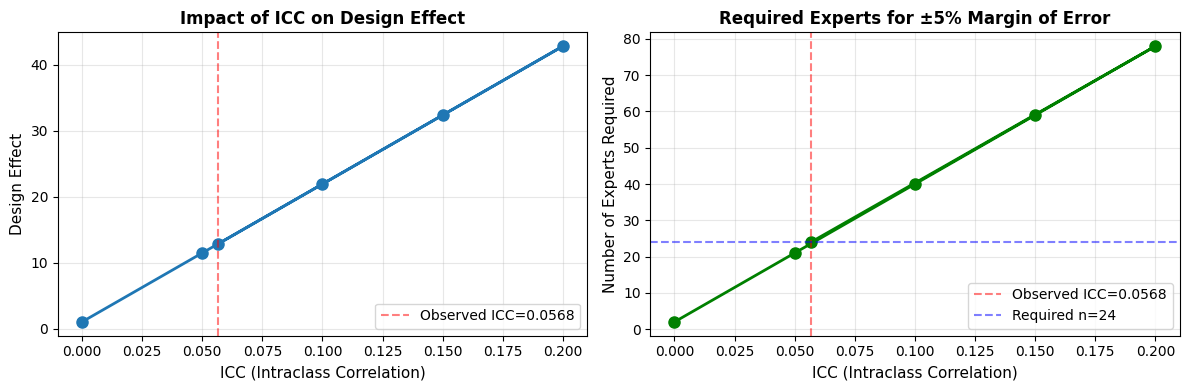


Saved sensitivity plot to charts/expert_sample_size_sensitivity.png


In [19]:
icc_values = [0.0, 0.05, 0.10, 0.15, 0.20, icc_expert]
p_test = 0.5  # worst case

print(f"Sensitivity Analysis: Required experts for ±{target_margin}% at different ICC values")
print(f"(proportion={p_test}, observations per expert={n_obs_per_expert})\n")

sensitivity_results = []
for icc in icc_values:
    n_req = required_experts_for_margin(target_margin, p_test, icc, n_obs_per_expert)
    deff = 1 + (n_obs_per_expert - 1) * icc
    sensitivity_results.append({
        'ICC': icc,
        'Design Effect': deff,
        'Experts Needed': n_req
    })
    print(f"  ICC={icc:.4f}: DEFF={deff:.2f}, n={n_req:3d} experts")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

icc_plot = [r['ICC'] for r in sensitivity_results]
deff_plot = [r['Design Effect'] for r in sensitivity_results]
n_plot = [r['Experts Needed'] for r in sensitivity_results]

ax1.plot(icc_plot, deff_plot, 'o-', linewidth=2, markersize=8)
ax1.axvline(icc_expert, color='red', linestyle='--', alpha=0.5, label=f'Observed ICC={icc_expert:.4f}')
ax1.set_xlabel('ICC (Intraclass Correlation)', fontsize=11)
ax1.set_ylabel('Design Effect', fontsize=11)
ax1.set_title('Impact of ICC on Design Effect', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.legend()

ax2.plot(icc_plot, n_plot, 'o-', linewidth=2, markersize=8, color='green')
ax2.axvline(icc_expert, color='red', linestyle='--', alpha=0.5, label=f'Observed ICC={icc_expert:.4f}')
ax2.axhline(n_required, color='blue', linestyle='--', alpha=0.5, label=f'Required n={n_required}')
ax2.set_xlabel('ICC (Intraclass Correlation)', fontsize=11)
ax2.set_ylabel('Number of Experts Required', fontsize=11)
ax2.set_title(f'Required Experts for ±{target_margin}% Margin of Error', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig('charts/expert_sample_size_sensitivity.pdf', dpi=200, bbox_inches='tight')
plt.show()
print(f"\nSaved sensitivity plot to charts/expert_sample_size_sensitivity.png")

In [20]:
# Compute variance components using ANOVA approach
# Between-expert variance
expert_counts = df_long.groupby('expert_id').size()
expert_means = df_long.groupby('expert_id')['permissible'].mean()
grand_mean = df_long['permissible'].mean()

# Between-expert sum of squares
ss_between_expert = sum(expert_counts * (expert_means - grand_mean)**2)
df_between_expert = len(expert_means) - 1
ms_between_expert = ss_between_expert / df_between_expert

# Within-expert variance
ss_within = sum((df_long['permissible'] - df_long['expert_id'].map(expert_means))**2)
df_within = len(df_long) - len(expert_means)
ms_within = ss_within / df_within

# ICC for experts
n_bar = len(df_long) / len(expert_means)  # average observations per expert
var_between_expert = (ms_between_expert - ms_within) / n_bar
var_within_expert = ms_within
icc_expert = var_between_expert / (var_between_expert + var_within_expert)

print(f"Variance Components (Experts):")
print(f"  Between-expert variance: {var_between_expert:.6f}")
print(f"  Within-expert variance: {var_within_expert:.6f}")
print(f"  ICC (expert): {icc_expert:.4f}")
print(f"  Average observations per expert: {n_bar:.1f}")

# Same for credentials
credential_counts = df_long.groupby('credential').size()
credential_means = df_long.groupby('credential')['permissible'].mean()

ss_between_credential = sum(credential_counts * (credential_means - grand_mean)**2)
df_between_credential = len(credential_means) - 1
ms_between_credential = ss_between_credential / df_between_credential

n_bar_cred = len(df_long) / len(credential_means)
var_between_credential = (ms_between_credential - ms_within) / n_bar_cred
icc_credential = var_between_credential / (var_between_credential + var_within_expert)

print(f"\nVariance Components (Credentials):")
print(f"  Between-credential variance: {var_between_credential:.6f}")
print(f"  ICC (credential): {icc_credential:.4f}")

# Same for categories
category_counts = df_long.groupby('category').size()
category_means = df_long.groupby('category')['permissible'].mean()

ss_between_category = sum(category_counts * (category_means - grand_mean)**2)
df_between_category = len(category_means) - 1
ms_between_category = ss_between_category / df_between_category

n_bar_cat = len(df_long) / len(category_means)
var_between_category = (ms_between_category - ms_within) / n_bar_cat
icc_category = var_between_category / (var_between_category + var_within_expert)

print(f"\nVariance Components (Categories):")
print(f"  Between-category variance: {var_between_category:.6f}")
print(f"  ICC (category): {icc_category:.4f}")

Variance Components (Experts):
  Between-expert variance: 0.007411
  Within-expert variance: 0.123147
  ICC (expert): 0.0568
  Average observations per expert: 210.0

Variance Components (Credentials):
  Between-credential variance: 0.008859
  ICC (credential): 0.0671

Variance Components (Categories):
  Between-category variance: 0.005113
  ICC (category): 0.0399


In [21]:
n_experts_current = 27
n_credentials = len(all_credentials)
n_categories = 15
n_obs_per_expert = n_credentials * n_categories
target_margin = 5  # ±5 percentage points

def required_experts_for_margin(target_margin_pct, p, icc, n_obs_per_expert):
    """Find number of experts needed for target margin of error."""
    target_margin = target_margin_pct / 100 
    
    # Binary search for required n_experts
    n_min, n_max = 1, 1000
    
    while n_max - n_min > 1:
        n_mid = (n_min + n_max) // 2
        n_eff = effective_sample_size(n_mid, n_obs_per_expert, icc)
        ci_width = wilson_ci_width(n_eff, p)
        margin = ci_width / 2
        
        if margin > target_margin:
            n_min = n_mid
        else:
            n_max = n_mid
    
    return n_max

print('=' * 80)
print('HIERARCHICAL DISAGREEMENT ANALYSIS (GLOBAL + RELATIVE BY CATEGORY)')
print('=' * 80)

hl_df = df_long[df_long['category'].notna()].copy()

model = mixedlm(
    "permissible ~ 1",
    data=hl_df,
    groups=hl_df["expert_id"],
    vc_formula={"category": "0 + C(category)"}
)

res = model.fit(
    reml=True,
    method="lbfgs",
    maxiter=200,
    disp=False
)

var_expert = (
    float(res.cov_re.iloc[0, 0])
    if hasattr(res, "cov_re") and not res.cov_re.empty
    else 0.0
)

var_category = (
    float(res.vcomp[0])
    if hasattr(res, "vcomp") and len(res.vcomp) > 0
    else 0.0
)

var_resid = float(res.scale)

var_total = var_expert + var_category + var_resid

expert_variance_share = var_expert / var_total if var_total > 0 else np.nan
category_variance_share = var_category / var_total if var_total > 0 else np.nan

print(f"Expert variance share (global):   {expert_variance_share:.4f}")
print(f"Category variance share (global): {category_variance_share:.4f}")
print(f"Residual variance share:          {var_resid / var_total:.4f}")

expert_cat_means = (
    hl_df
    .groupby(["category", "expert_id"])["permissible"]
    .mean()
)

category_dispersion = (
    expert_cat_means
    .groupby("category")
    .var()
    .rename("expert_mean_variance")
)

relative_disagreement = (
    category_dispersion / category_dispersion.mean()
).rename("relative_disagreement")

category_disagreement_table = (
    pd.concat([category_dispersion, relative_disagreement], axis=1)
      .reset_index()
      .sort_values("relative_disagreement", ascending=False)
)

print("\nRelative disagreement by category (>=1 = above average):\n")
print(category_disagreement_table)

category_disagreement_table_rounded = category_disagreement_table.copy()
category_disagreement_table_rounded['expert_mean_variance'] = category_disagreement_table_rounded['expert_mean_variance'].round(4)
category_disagreement_table_rounded['relative_disagreement'] = category_disagreement_table_rounded['relative_disagreement'].round(4)
category_disagreement_table_rounded.to_csv(
    "tables/expert_disagreement_by_category.csv",
    index=False
)

print("\nSaved: tables/expert_disagreement_by_category.csv")

icc_for_planning = min(max(expert_variance_share, 0.01), 0.20)

print(f"\nPlanning ICC (clamped): {icc_for_planning:.4f}")

n_obs_per_expert = n_credentials * n_categories

n_required_global = required_experts_for_margin(
    target_margin,
    p=0.5,
    icc=icc_for_planning,
    n_obs_per_expert=n_obs_per_expert
)


HIERARCHICAL DISAGREEMENT ANALYSIS (GLOBAL + RELATIVE BY CATEGORY)
Expert variance share (global):   0.0000
Category variance share (global): 0.9412
Residual variance share:          0.0588

Relative disagreement by category (>=1 = above average):

              category  expert_mean_variance  relative_disagreement
5           Government              0.109778               4.286444
7           Job Portal              0.080988               3.162292
14          University              0.044096               1.721802
10    Payment Services              0.032458               1.267382
9       Online Doctors              0.025791               1.007030
11            Pharmacy              0.018726               0.731191
1                 Bank              0.016063               0.627204
2           Car Rental              0.014405               0.562461
6   Int. Ground Travel              0.014230               0.555650
0           Air Travel              0.008214               0.320717
12 

c:\Users\zingg\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1533: RuntimeWarning: divide by zero encountered in log
  cov_aug_logdet = cov_re_logdet + np.sum(np.log(vc_var))
c:\Users\zingg\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1537: RuntimeWarning: divide by zero encountered in divide
  solver = _smw_solver(1., ex_r, ex2_r, cov_re_inv, 1 / vc_var)
c:\Users\zingg\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1542: RuntimeWarning: divide by zero encountered in divide
  ld = _smw_logdet(1., ex_r, ex2_r, cov_re_inv, 1 / vc_var,
c:\Users\zingg\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:573: RuntimeWarning: invalid value encountered in scalar add
  return B_logdet + ld + ld1
c:\Users\zingg\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmode

## Generate tables showing how many experts picked a credential in the survey for website x credential pair in never, would give, and is necessary

In [22]:
SRC = Path('data/credential_percentage_per_category_expert.txt')

if not SRC.exists():
    raise FileNotFoundError(f"Source file not found: {SRC}")

block_header_re = re.compile(r"^Percentage of .+:\s*$", re.IGNORECASE)
type_re = re.compile(r"^Type:\s*(\S.+)\s*$", re.IGNORECASE)
cat_re = re.compile(r"^\s*-\s*([^:]+):\s*$")
cred_pct_re = re.compile(r"^\s*-\s*([^:]+):\s*([0-9]+(?:\.[0-9]+)?)%")

data = {} 
block_titles = {}  

current_type = None
current_block_idx = None
current_category = None
in_block = False

with open(SRC, 'r', encoding='utf-8') as f:
    for raw in f:
        line = raw.rstrip('\n')
        if not line.strip():
            continue
        if block_header_re.match(line):
            in_block = True
            current_type = None
            current_block_idx = None
            current_category = None
            last_header = line.strip()
            continue
        mtype = type_re.match(line)
        if in_block and mtype:
            current_type = mtype.group(1).strip()
            data.setdefault(current_type, [])
            data[current_type].append({})
            block_titles.setdefault(current_type, []).append(last_header)
            current_block_idx = len(data[current_type]) - 1
            current_category = None
            continue
        if in_block and current_type is not None:
            mcat = cat_re.match(line)
            if mcat:
                current_category = mcat.group(1).strip()
                data[current_type][current_block_idx].setdefault(current_category, {})
                continue
            mcred = cred_pct_re.match(line)
            if mcred and current_category is not None:
                cred = mcred.group(1).strip()
                pct = float(mcred.group(2))
                data[current_type][current_block_idx].setdefault(current_category, {})[cred] = pct
                continue

for typ, blocks in data.items():
    for bi, block in enumerate(blocks[:2]):
        creds_set = set()
        categories = list(block.keys())
        for cat in categories:
            creds_set.update(block.get(cat, {}).keys())
        creds = sorted(creds_set)
        df = pd.DataFrame(index=creds, columns=categories)
        for cat in categories:
            for cred in creds:
                val = block.get(cat, {}).get(cred)
                df.at[cred, cat] = f"{val:.2f}%" if val is not None else ''
        sanitized_type = typ.strip().replace(' ', '_')
        if bi == 1:
            out_name = f"expert_{sanitized_type}_permissible_credentials.csv"
        else:
            if typ.strip().lower() == 'law':
                out_name = f"expert_{sanitized_type}_necessary_credentials.csv"
            else:
                out_name = f"expert_{sanitized_type}_never_credentials.csv"
        out_path = OUT_DIR / out_name
        df.to_csv(out_path, index=True)
        print(f"Wrote expert table: {out_path}")


Wrote expert table: tables\expert_cybersecurity_never_credentials.csv
Wrote expert table: tables\expert_cybersecurity_permissible_credentials.csv
Wrote expert table: tables\expert_law_necessary_credentials.csv
Wrote expert table: tables\expert_law_permissible_credentials.csv
Wrote expert table: tables\expert_policy_never_credentials.csv
Wrote expert table: tables\expert_policy_permissible_credentials.csv
Wrote expert table: tables\expert_ethics_never_credentials.csv
Wrote expert table: tables\expert_ethics_permissible_credentials.csv


In [23]:
#Combined
credential_order = [
    'Official ID', "Driver'S License", 'Birth Certificate', 'Marriage Certificate', 'Visa',
    'Bank Acc. Validation', 'University Transcript', 'Diploma', 'Employment History',
    'Professional Licenses', 'Health Insurance', 'Prescriptions', 'Medical Records', 'Disability Status'
]

category_order = [
    'Pharmacy', 'Online Doctors', 'Government', 'Job Portal', 'University',
    'Air Travel', 'Int. Ground Travel', 'Car Rental', 'Bank', 'Real Estate',
    'Gaming', 'E-commerce', 'Social Media', 'News', 'Payment Services'
]

# Number of experts in each domain
NUM_CYBER = 15
NUM_POLICY = 5
NUM_ETHICS = 4
TOTAL_EXPERTS = NUM_CYBER + NUM_POLICY + NUM_ETHICS  # 24 experts total

never_cyber = pd.read_csv('tables/expert_cybersecurity_never_credentials.csv', index_col=0)
never_policy = pd.read_csv('tables/expert_policy_never_credentials.csv', index_col=0)
never_ethics = pd.read_csv('tables/expert_ethics_never_credentials.csv', index_col=0)

never_cyber_numeric = never_cyber.copy()
never_policy_numeric = never_policy.copy()
never_ethics_numeric = never_ethics.copy()

for col in never_cyber_numeric.columns:
    never_cyber_numeric[col] = never_cyber_numeric[col].str.rstrip('%').astype(float) / 100 * NUM_CYBER

for col in never_policy_numeric.columns:
    never_policy_numeric[col] = never_policy_numeric[col].str.rstrip('%').astype(float) / 100 * NUM_POLICY

for col in never_ethics_numeric.columns:
    never_ethics_numeric[col] = never_ethics_numeric[col].str.rstrip('%').astype(float) / 100 * NUM_ETHICS

never_combined_counts = never_cyber_numeric + never_policy_numeric + never_ethics_numeric

never_combined = never_combined_counts / TOTAL_EXPERTS * 100

never_combined.rename(columns={'International Ground Travel': 'Int. Ground Travel'}, inplace=True)
never_combined.rename(index={'Bank credentials': 'Bank Acc. Validation', 'Bank Credentials': 'Bank Acc. Validation'}, inplace=True)
never_combined.rename(index={'Official Identity Document': 'Official ID'}, inplace=True)
never_combined.index = never_combined.index.str.title()
never_combined.rename(index={'Official Id': 'Official ID'}, inplace=True)

never_combined = never_combined.reindex(index=credential_order, columns=category_order)

never_combined = never_combined.round(2).astype(str) + '%'

never_combined.to_csv('tables/expert_combined_never_credentials.csv')
print("Saved: expert_combined_never_credentials.csv")
print(never_combined)

perm_cyber = pd.read_csv('tables/expert_cybersecurity_permissible_credentials.csv', index_col=0)
perm_policy = pd.read_csv('tables/expert_policy_permissible_credentials.csv', index_col=0)
perm_ethics = pd.read_csv('tables/expert_ethics_permissible_credentials.csv', index_col=0)

perm_cyber_numeric = perm_cyber.copy()
perm_policy_numeric = perm_policy.copy()
perm_ethics_numeric = perm_ethics.copy()

for col in perm_cyber_numeric.columns:
    perm_cyber_numeric[col] = perm_cyber_numeric[col].str.rstrip('%').astype(float) / 100 * NUM_CYBER

for col in perm_policy_numeric.columns:
    perm_policy_numeric[col] = perm_policy_numeric[col].str.rstrip('%').astype(float) / 100 * NUM_POLICY

for col in perm_ethics_numeric.columns:
    perm_ethics_numeric[col] = perm_ethics_numeric[col].str.rstrip('%').astype(float) / 100 * NUM_ETHICS

perm_combined_counts = perm_cyber_numeric + perm_policy_numeric + perm_ethics_numeric

perm_combined = perm_combined_counts / TOTAL_EXPERTS * 100

perm_combined.rename(columns={'International Ground Travel': 'Int. Ground Travel'}, inplace=True)
perm_combined.rename(index={'Bank credentials': 'Bank Acc. Validation', 'Bank Credentials': 'Bank Acc. Validation'}, inplace=True)
perm_combined.rename(index={'Official Identity Document': 'Official ID'}, inplace=True)
perm_combined.index = perm_combined.index.str.title()
perm_combined.rename(index={'Official Id': 'Official ID'}, inplace=True)

perm_combined = perm_combined.reindex(index=credential_order, columns=category_order)

perm_combined = perm_combined.round(2).astype(str) + '%'

perm_combined.to_csv('tables/expert_combined_permissible_credentials.csv')
print("\nSaved: expert_combined_permissible_credentials.csv")
print(perm_combined)

Saved: expert_combined_never_credentials.csv
                      Pharmacy Online Doctors Government Job Portal  \
Official ID              25.0%         33.33%       0.0%      37.5%   
Driver'S License        83.33%         83.33%      8.34%      50.0%   
Birth Certificate       70.83%         66.67%      12.5%      75.0%   
Marriage Certificate     87.5%         83.33%      12.5%     79.17%   
Visa                    91.66%         91.66%     16.66%     58.33%   
Bank Acc. Validation     62.5%          75.0%      50.0%     79.17%   
University Transcript   91.66%         95.83%     54.17%     29.17%   
Diploma                 95.83%         95.83%     41.66%     16.67%   
Employment History      95.83%          87.5%      37.5%      12.5%   
Professional Licenses    87.5%         95.83%     29.17%      12.5%   
Health Insurance        16.67%          4.17%      37.5%     91.67%   
Prescriptions            8.33%          12.5%      75.0%     91.67%   
Medical Records         58.34%  

## Generate the table comparing the sharing behavior of the 18-29 age group and the 50+ age group

In [24]:
SPLIT_SRC = Path('aggregate_demographics_data/credential_percentage_per_category_split.txt')
if not SPLIT_SRC.exists():
    raise FileNotFoundError(f'Source file not found: {SPLIT_SRC}')

attr_re = re.compile(r'^Attribute:\s*(.+)\s*$')
cat_re = re.compile(r"^-\s*([^:]+):\s*$")
line_counts_re = re.compile(r"^\s*-\s*([^:]+):\s*([0-9]+(?:\.[0-9]+)?)%\s*\((\d+)\s*/\s*(\d+)\)")

counts_split = {}
categories_order_split = []
with open(SPLIT_SRC, 'r', encoding='utf-8') as f:
    current_attr = None
    current_cat = None
    for raw in f:
        line = raw.rstrip('\n')
        if not line.strip():
            continue

        mattr = attr_re.match(line)
        if mattr:
            current_attr = mattr.group(1).strip()
            counts_split.setdefault(current_attr, {})
            current_cat = None
            continue

        mcat = cat_re.match(line)
        if mcat:
            current_cat = mcat.group(1).strip()
            if current_cat not in categories_order_split:
                categories_order_split.append(current_cat)
            if current_attr is not None:
                counts_split.setdefault(current_attr, {})
                counts_split[current_attr].setdefault(current_cat, {})
            continue

        if current_attr is None or current_cat is None:
            continue

        m = line_counts_re.match(line)
        if m:
            cred = m.group(1).strip()
            num = int(m.group(3))
            den = int(m.group(4))
            counts_split[current_attr][current_cat][cred] = (num, den)
        else:
            m2 = re.match(r"^\s*-\s*([^:]+):\s*([0-9]+(?:\.[0-9]+)?)%\s*\((\d+)\s*/\s*(\d+)\)", line)
            if m2:
                cred = m2.group(1).strip()
                num = int(m2.group(3))
                den = int(m2.group(4))
                counts_split[current_attr][current_cat][cred] = (num, den)
            else:
                continue

pairs = [
    ('age_18_29','age_50_plus','chi2_age_18_29_vs_50_plus.csv'),
]

for first, second, filename in pairs:
    rows = []
    for cat in categories_order_split:
        first_map = counts_split.get(first, {}).get(cat, {})
        second_map = counts_split.get(second, {}).get(cat, {})
        creds = set(first_map.keys()) | set(second_map.keys())
        for cred in sorted(creds):
            if cred in first_map and cred in second_map:
                fn, fd = first_map[cred]
                sn, sd = second_map[cred]
                table = [[fn, fd - fn], [sn, sd - sn]]
                try:
                    chi2, p, dof, exp = chi2_contingency(table, correction=False)
                except Exception:
                    chi2, p, dof, exp = (None, None, None, None)
                use_fisher = False
                try:
                    if exp is not None and (np.array(exp) < 5).any():
                        use_fisher = True
                except Exception:
                    use_fisher = False
                if use_fisher:
                    try:
                        _, p_f = fisher_exact(table)
                    except Exception:
                        p_f = None
                    pval = p_f
                else:
                    pval = p
                first_pct = (fn / fd) * 100 if fd and fd > 0 else None
                second_pct = (sn / sd) * 100 if sd and sd > 0 else None
                pct_diff = (first_pct - second_pct) if (first_pct is not None and second_pct is not None) else None
                rows.append({
                    'Website category': cat,
                    'Credential': cred,
                    f'{first} Total #': fd if fd is not None else '',
                    f'{first} Accept #': fn if fn is not None else '',
                    f'{first} Accept %': f"{first_pct:.2f}%" if first_pct is not None else '',
                    f'{second} Total #': sd if sd is not None else '',
                    f'{second} Accept #': sn if sn is not None else '',
                    f'{second} Accept %': f"{second_pct:.2f}%" if second_pct is not None else '',
                    'Difference %': f"{pct_diff:.2f}%" if pct_diff is not None else '',
                    'Chi2 Value': round(chi2,2) if chi2 is not None else '',
                    'p-Value': round(pval,4) if pval is not None else ''
                })
    safe_filename = filename.replace('+', 'plus')
    out = OUT_DIR / safe_filename
    fieldnames = ['Website category','Credential',f'{first} Total #',f'{first} Accept #',f'{first} Accept %',f'{second} Total #',f'{second} Accept #',f'{second} Accept %','Difference %','Chi2 Value','p-Value']
    with out.open('w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for r in rows:
            writer.writerow(r)
    print('Wrote attribute chi2 file:', out)

print('\nGenerated attribute chi2 files in tables/:')
for p in sorted(OUT_DIR.iterdir()):
    if p.name.startswith('chi2_') and ('male' in p.name or 'age' in p.name or 'hs' in p.name or 'italy' in p.name or 'bsc' in p.name or 'msc' in p.name or 'phd' in p.name):
        print('-', p.name)


Wrote attribute chi2 file: tables\chi2_age_18_29_vs_50_plus.csv

Generated attribute chi2 files in tables/:
- chi2_age_18_29_vs_50_plus.csv


## Generate table showing the credential frquency of use and sensitivity analysis

In [25]:
SRC = Path('data/comfort_frequency_breakdown.txt')

if not SRC.exists():
    raise FileNotFoundError(f"Source file not found: {SRC}")

cred_re = re.compile(r"^\s*-\s*(.+?):\s*$")
avg_freq_re = re.compile(r"^\s*-\s*Average frequency:\s*([0-9]+(?:\.[0-9]+)?)\s*\((\d+)\)\s*$")
avg_comfort_re = re.compile(r"^\s*-\s*Average comfort:\s*([0-9]+(?:\.[0-9]+)?)\s*\((\d+)\)\s*$")
avg_still_re = re.compile(r"^\s*-\s*Average still share:\s*([0-9]+(?:\.[0-9]+)?)\s*\((\d+)\)\s*$")

rows = []
current_cred = None
with open(SRC, 'r', encoding='utf-8') as f:
    for raw in f:
        line = raw.rstrip('\n')
        if not line.strip():
            continue
        mcred = cred_re.match(line)
        if mcred:
            current_cred = mcred.group(1).strip()
            freq_val = None
            freq_n = ''
            comfort_val = None
            comfort_n = ''
            still_val = None
            still_n = ''
            continue
        if current_cred is None:
            continue
        mfreq = avg_freq_re.match(line)
        if mfreq:
            freq_val = float(mfreq.group(1))
            freq_n = int(mfreq.group(2))
            continue
        mcomf = avg_comfort_re.match(line)
        if mcomf:
            comfort_val = float(mcomf.group(1))
            comfort_n = int(mcomf.group(2))
            continue
        mstill = avg_still_re.match(line)
        if mstill:
            still_val = float(mstill.group(1))
            still_n = int(mstill.group(2))
            rows.append({
                'Credential': current_cred,
                'Own Credential #': freq_n if freq_n != '' else '',
                'Average Frequency of Use': round(freq_val, 2) if freq_val is not None else '',
                'Average Comfort': round(comfort_val, 2) if comfort_val is not None else '',
                'Not Fully Comfortable #': still_n if still_n != '' else '',
                'Average Still Share': round(still_val, 2) if still_val is not None else ''
            })
            current_cred = None

df = pd.DataFrame(rows, columns=['Credential','Own Credential #','Average Frequency of Use','Average Comfort','Not Fully Comfortable #','Average Still Share'])
out = OUT_DIR / 'comfort_by_credential.csv'
df.to_csv(out, index=False)
print('Wrote comfort CSV:', out)

Wrote comfort CSV: tables\comfort_by_credential.csv
